# Mindestanforderungen 5 - Clustering
- Clusteranalyse durchführen
    - wir haben eine Clusteranalyse auf einen zuvor bereinigten Datensatz mit MiniBatchKMeans durchgeführt
    - Feature-Set waren hierbei eine Kombination aus numerischen und Textspalten.
    - Ziel war es einen groben Überblick über die Entwicklerprofile zu erhalten
- Parameter
    - die Clusteranzahl haben wir über die unüberwachte Evaluationsmethode, mit der Elbow-Methode, gewählt
    - dazu wurden jeweils die Inerita (Sum of Squared Errors) für k von 2-20 berechnet, geplottet und anschließend die passendste Clustergröße gewählt
    - wir haben uns gegen die überwachte Evaluationsmethode entschieden, da wir keine überwachten Metriken haben
    - Silhouetten-Score wurde auf "Empfehlung" von Herrn Speiser nicht betrachtet
- erzeugte Cluster
    - Cluster zeigen sinnvolle Profile
    - Teilweise entstehen Cluster, die stark durch Missingness geprägt sind, kommt durch viele fehlende Werte im Datensatz
- Weiter Nutzung
    - wir wollen die Cluster als "Entwicklerprofile" interpretieren und pro Cluster Kennzahlen oder typische Tools reporten
    - zudem konnten wir bereits durch mehrere Iterationen des Clusterings Outlier erkennen und diese im Cleanup-Notebook ausschließen, da sie klare Datenfehler waren (Gehalt extrem hoch, WorkExp und YearsCode ~100)

Einlesen des Datensatzes, welcher zuvor im `Cleanup`-Notebook vorbereitet wurde

In [81]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

# -------------------------
# 0) Laden
# -------------------------
df = pd.read_csv("survey_results_cleaned_final.csv")
print("Loaded:", df.shape)
salary_col = "ConvertedCompTotal"
before = df.shape
df = df.dropna(subset=[salary_col])
df = df[df[salary_col] > 1000]
print(f"Dropped salary NaNs ({salary_col}): {before} -> {df.shape}")

df.to_csv("survey_results_after_clustering.csv", index=False)
print("Saved clustering base:", df.shape, "->", "survey_results_after_clustering.csv")

Loaded: (20603, 40)
Dropped salary NaNs (ConvertedCompTotal): (20603, 40) -> (14687, 40)
Saved clustering base: (14687, 40) -> survey_results_after_clustering.csv


- Alle numerischen Spalten zwischenspeichern
- einzelne Spalten, welche für Clustering nicht benötigt werden oder Cluster verzerren, entfernen (Age wird als String später drin sein)
- durch `num_imputer` werden NaN-Werte spaltenweise durch Median der jeweiligen Spalte ersetzt (nicht immer sinnvoll)
    - wenn NaN gedroppt werden würde, würden wir viele Spalten verlieren, Median ist zudem robust gegen Ausreißer
    - Alternativ haben wir auch bei einer Spalte ein Missing Flag hinzugefügt, wo der Median keinen Sinn macht (`RemoteMissing`)
- `StandardScaler` macht jede numerische Spalte vergleichbar durch z-Score Scaling
    - Scaling wichtig, da sonst Features mit großen Zahlenbereichen alles dominieren würden
    - für KMeans praktisch pflicht, da sonst Distanzen nicht fair

In [55]:
num_cols_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
drop_num = {"ResponseId", "MaxAge","AgeNum"}  # falls vorhanden
num_cols = [c for c in num_cols_all if c not in drop_num]

X_num_raw = df[num_cols].apply(pd.to_numeric, errors="coerce")

if salary_col in X_num_raw.columns:
    df[f"{salary_col}_raw"] = X_num_raw[salary_col]          # fürs spätere Reporting
    X_num_raw[salary_col] = np.log1p(X_num_raw[salary_col])  # fürs Clustering

num_imputer = SimpleImputer(strategy="median")
num_scaler = StandardScaler()

X_num_imp = num_imputer.fit_transform(X_num_raw)
X_num = num_scaler.fit_transform(X_num_imp)

print("Numeric cols:", len(num_cols))

Numeric cols: 6


- Zwischenspeichern aller Text-/Kategoriespalten -> für TF-IDF später
- herausfiltern einzelner Spalten, analog numerischer Spalten
    - Country: Demografischer Aspekt weglassen
    - RemoteWork ist als Zahlenskala schon dabei
- erkennen der Multi-Select Spalten anhand des Semikolons (wenn Anteil Semikolons höher der Schwelle -> Multi-Select
    - Multi-Select wird später anders tokenisiert werden, da es zuerst gesplittet werden muss und mehrere Tokens pro Zeile gibt
- Aufteilen der Mulit-Select und Single-Select spalten für späteres Dokument bauen mit dem TF-IDF Vectorizer
- Herausfiltern der Single-Choice Freitext Felder
    - Spalten mit 2-200 verschiedenen Einträgen werden behalten, 200 als grober Richtwert

In [56]:
obj_cols_all = df.select_dtypes(include=["object"]).columns.tolist()

# Spalten, die häufig dominieren / wenig Profilwert haben
hard_exclude = {"Country", "RemoteWork"}  # optional erweitern
obj_cols_all = [c for c in obj_cols_all if c not in hard_exclude]
obj_cols_all = [c for c in obj_cols_all if "Choice" not in c]

def is_multiselect(col, threshold=0.05):
    s = df[col].astype(str)
    return (s.str.contains(";", na=False).mean() >= threshold)

multi_cols = [c for c in obj_cols_all if is_multiselect(c)]
single_cols = [c for c in obj_cols_all if c not in multi_cols]

# Single-choice: zu viele Uniques = eher Freitext => raus
nunique = df[single_cols].nunique(dropna=True)
single_cols = nunique[(nunique >= 2) & (nunique <= 200)].index.tolist()

print("Multi cols:", len(multi_cols))
print("Single cols:", len(single_cols))

Multi cols: 10
Single cols: 13


In [57]:
TOPN = 10

def build_top_map_for_multicols(df, multi_cols, topn=10):
    top_map = {}
    for col in multi_cols:
        s = df[col].dropna().astype(str)
        items = s.str.split(";").explode().str.strip().str.lower()
        items = items[items != ""]
        top_vals = items.value_counts().head(topn).index.tolist()
        top_map[col] = set(top_vals)
    return top_map

top_map = build_top_map_for_multicols(df, multi_cols, topn=TOPN)
print("Top-map built for multi-cols:", len(top_map))

Top-map built for multi-cols: 10


- hier werden aus einzelnen Zeilen Dokumente gebaut für Vectorizer
- `parse_semicolon_list` erzeugt leere Listen, wenn NaN-Werte vorhanden sind, ansonsten splitten nach Semikolon und alles lowercase machen für besseres Handling
- `normalize_token` ersezte Leerzeichen mit Unterstrichen und setzt den token auf lowercase
    - dadurch wird verhindert, dass aus bspw. `visual studio code` nicht als drei getrennte Tokens erkannt werden
- bei `row_to_doc` werden dann pro person bzw. Zeile eine Liste von Tokens erzeugt
    - am Ende aus allen Tokens ein großer String im Stil `Spalte_Wert`
    - NaN-Werte werden geskippt, da uns eigentlich ja nur ausgefüllt Werte interessieren
- Warum das Ganze?
    - der TFIDF-Vectorizer erwartet eine Liste an Dokumenten, weshalb wir für jede Zeile/Person ein Dokument bauen

In [58]:
def parse_semicolon_list(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "":
        return []
    return [p.strip().lower() for p in s.split(";") if p.strip()]

def normalize_token(t: str) -> str:
    t = t.strip().lower()
    t = re.sub(r"\s+", "_", t)
    return t

def row_to_doc(row) -> str:
    tokens = []

    # =========================
    # ✅ NEU: Multi-select (TopN + other)
    # =========================
    for col in multi_cols:
        seen_other = False

        for t in parse_semicolon_list(row[col]):  # liefert lowercase
            if t in top_map[col]:
                tokens.append(f"{col}__{normalize_token(t)}")
            else:
                seen_other = True

        if seen_other:
            tokens.append(f"{col}__other")

    # Single-choice (wie gehabt)
    for col in single_cols:
        v = row[col]
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v:
            tokens.append(f"{col}__{normalize_token(v)}")

    return " ".join(tokens)

docs = df.apply(row_to_doc, axis=1)

- hier werden aus den zuvor erzeugten Dokumenten eine numerische Feature-Matrix erstellt, um später alles zusammenzuwerfen und zu clustern
- TFIDF-Vectorizer
    - macht Matrix aus Spalte_Wert:
        - Zeilen/Dokumente = Personen
        - Spalten = Tokens
        - Werte = TFIDF-Gewichte, also wie "typisch" der Token für die Person ist
    - Tokens sind durch Leerzeichen getrennt, deshalb `str.split`
    - `token_pattern = None`, weil Vectorizer sonst sein eigenes Tokenizing erzwingen würde
    - `lowercase=False`, wurde vorher schon erledigt, wäre hier redundant
    - *minimum document frequency* -> ein Token muss in mindestens 50 Personen vorkommen, sonst fliegt er raus
        - so können extrem seltene Tokens rausgeworfen werden, die eher Nischen widerspiegeln
    - *max features*, begrenzt Anzahl der Tokenspalten auf 10.000
    - `fit_transform` baut Vokabular aus Tokens und erstellt Sparse Matrix der TFIDF Werte

In [74]:
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False,
    min_df=50,
    max_features=10000
)

X_text = vectorizer.fit_transform(docs)
print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (14687, 209)


- Zusammenfügen der Numerischen und Textuellen Features zu gemeinsamen Feature Set für Clustering
- `X_num` kommt vom StandardScaler der numerischen Werte
- `X_test` kommt aus dem TFIDF Vectorizer
- `hstack` = horizontal stack -> Features nebeneinander
    - so sind weiterhin gleiche Anzahl an Zeilen/Personen
    - aber Spalten sind nun Numerische Features und TFIDF-Tokens
- `.tocsr()` konvertiert resultierende Matix explizit in CSR Format (Compressed Row Sotrage)
    - *The CSR format is optimized for fast row slicing and matrix-vector products. It compresses the sparse matrix by storing only the non-zero elements and the corresponding row indices. The structure is divided into three one-dimensional arrays*

In [75]:
X_all = hstack([csr_matrix(X_num), X_text]).tocsr()
print("Final X_all shape:", X_all.shape)

Final X_all shape: (14687, 215)


- Anzahl Cluster von 2-20 testen
- `ineritas` sammelt die jeweilige Ineritas Qualität für das k
- `MiniBatchKMeans` ist eine Variante von KMeans, welche schneller bei großen/hohen Dimensionen ist, weil sie eben in Minibatches arbeitet
    - sinnvoll, da unser Datensatz groß ist
- `km_tmp.inerita_` summiert die quadrierten Abstände aller Punkte, somit können wir in dem Graphen den Elbow suchen und anschließend das beste *k* auswählen

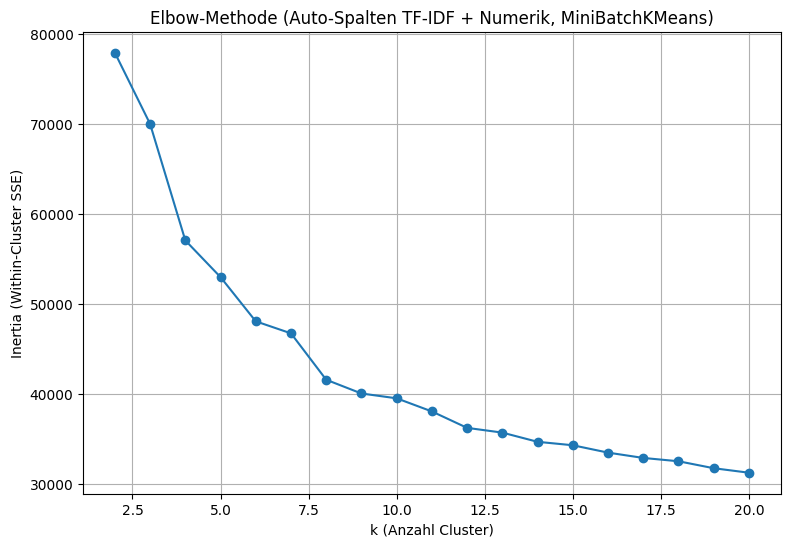

In [76]:
k_values = list(range(2, 21))
inertias = []

for kk in k_values:
    km_tmp = MiniBatchKMeans(n_clusters=kk, random_state=42, batch_size=2048, n_init=10)
    km_tmp.fit(X_all)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow-Methode (Auto-Spalten TF-IDF + Numerik, MiniBatchKMeans)")
plt.grid(True)
plt.show()

- aus Elbowplot wurde k=7 am besten empfunden
- Silhouette weggelassen aufgrund Empfelung von Hr. Speiser
- anschließend Clustering-Modell erstellen mit denselben Parametern wie zuvor
- `fit.predict` durch das *fit* "lernt" das Modell die 7 Clusterzentren auf Basis der zuvor erstellten Feature-Matrix`X_all`, *predict* weißt anschließend jede Zeile/Person einem Cluster zu

In [77]:
k = 8  # <- nach Elbow wählen
km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init=10)
labels = km.fit_predict(X_all)

- hier werden interpretierbare Cluster erstellt
- Wir erhalten die:
    - Clustergrößen
    - Numerik-Mittelwerte
    - Cluster-Zentren
    - Top IFIDF Tokens pro Cluster
    - Top Kategorien


In [78]:
df_out = df.copy()
df_out["cluster"] = labels

# A) Clustergrößen + Prozent
sizes = df_out["cluster"].value_counts().sort_index()
summary = pd.DataFrame({
    "n": sizes,
    "pct": (sizes / sizes.sum() * 100).round(2)
})
print("\nClustergrößen:")
print(summary)

report_num_cols = num_cols.copy()
if f"{salary_col}_raw" in df_out.columns and salary_col in report_num_cols:
    report_num_cols = [c for c in report_num_cols if c != salary_col] + [f"{salary_col}_raw"]

# B) Numerik-Mittelwerte pro Cluster (Original-Skala)
print("\nNumerik-Mittelwerte pro Cluster (Original-Skala):")
print(df_out.groupby("cluster")[report_num_cols].mean().round(2))

# C) Numerik-Zentren (aus KMeans-Zentren zurücktransformiert)
centers_scaled_num = km.cluster_centers_[:, :len(num_cols)]
centers_num = num_scaler.inverse_transform(centers_scaled_num)
centers_num = pd.DataFrame(centers_num, columns=num_cols)
centers_num.index.name = "cluster"

if salary_col in centers_num.columns:
    centers_num[salary_col] = np.expm1(centers_num[salary_col])

print("\nCluster-Zentren (Numerik, Original-Skala):")
print(centers_num.round(2))

# D) Top TF-IDF Tokens pro Cluster
terms = vectorizer.get_feature_names_out()
centers_text = km.cluster_centers_[:, len(num_cols):]

top_n = 12
print("\nTop TF-IDF Tokens pro Cluster:")
for cl in range(km.n_clusters):
    top_idx = np.argsort(centers_text[cl])[::-1][:top_n]
    print(f"\nCluster {cl} (n={int(sizes.get(cl, 0))}):")
    for j in top_idx:
        print(f"  {terms[j]}  ({centers_text[cl][j]:.4f})")

# E) Optional: Top-Kategorien pro Cluster (nur falls vorhanden)
cat_check = ["Employment", "MainBranch", "RemoteWork", "Industry"]
for col in cat_check:
    if col in df_out.columns:
        print(f"\nTop {col} pro Cluster (Anteil):")
        tmp = (df_out.groupby("cluster")[col]
               .value_counts(normalize=True)
               .rename("share")
               .reset_index()
               .sort_values(["cluster", "share"], ascending=[True, False])
               .groupby("cluster")
               .head(3))
        print(tmp)


Clustergrößen:
            n    pct
cluster             
0        1872  12.75
1        3514  23.93
2        2447  16.66
3         745   5.07
4        1192   8.12
5        3132  21.32
6        1163   7.92
7         622   4.24

Numerik-Mittelwerte pro Cluster (Original-Skala):
         WorkExp  YearsCode  RemoteCategoryNum  JobSat  RemoteMissing  \
cluster                                                                 
0          19.06      24.44               0.73    7.62           0.00   
1           8.31      12.15               0.10    7.69           0.00   
2          20.32      25.31               0.10    7.67           0.00   
3           8.59      11.71               0.50    6.92           1.00   
4           5.20       8.33               0.53    7.15           0.00   
5           6.62      11.07               0.76    7.68           0.00   
6           9.67      14.46               0.45    3.22           0.01   
7          20.49      25.70               0.50    7.55           1

**Nur für Visualisierung**
- Dimensions-Reduktion, die sehr hochdimensionale Matrix auf 2 Komponenten herunterbricht
- TruncatedSVD funktioniert gut für sparse Matrizen, PCA zetriert meist und braucht dense Matrizen
- zeichnet jeden Datenpunkt als Punkt im 2D-Raum eingefärbt nach Cluster

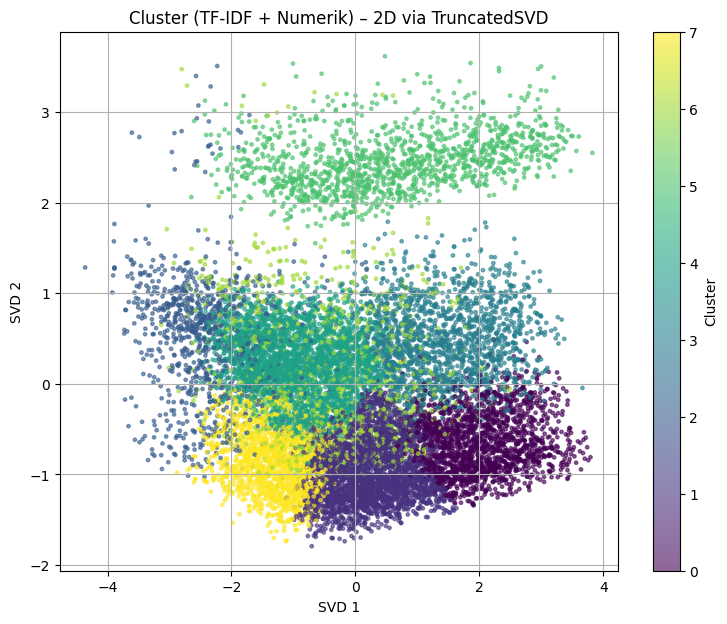

In [73]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_all)

plt.figure(figsize=(9, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=6, alpha=0.6)
plt.title("Cluster (TF-IDF + Numerik) – 2D via TruncatedSVD")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


In [43]:
df_out.loc[df_out.cluster==3, "ConvertedCompTotal"].describe()

count       784.000000
mean      69697.735699
std       50998.643141
min         600.000000
25%       30203.988036
50%       60487.037194
75%       99263.000000
max      235000.000000
Name: ConvertedCompTotal, dtype: float64